In [31]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, BaseMessage
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [32]:
load_dotenv()

True

In [33]:
from langgraph.graph.message import add_messages

class Chatstate(TypedDict):
    
    messages: Annotated[list[BaseMessage], add_messages]

In [34]:
# our llm
LLM = ChatGroq(model="openai/gpt-oss-20b", temperature=0.5)

In [35]:
def chat_node(state: Chatstate):
    
    # we will get the human query 
    messages = state['messages']
    
    # give it to llm for response
    response = LLM.invoke(messages)
    # return the response
    return {'messages': [response]}

In [36]:
checkpointer = MemorySaver()
# graph
graph = StateGraph(Chatstate)

# node
graph.add_node("chat_node", chat_node)

# edge
graph.add_edge(START, "chat_node")

graph.add_edge("chat_node", END)


chatbot = graph.compile(checkpointer=checkpointer)

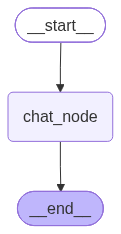

In [37]:
chatbot

In [27]:
initial_state = {
    'messages': [HumanMessage(content="What is the capitol of india?")]
}

# chatbot.invoke(initial_state)

In [28]:
thread_id = '1'

# now lets create it properly
while True:
    
    user_message = input("type_here: ")
    
    print('user: ', user_message)
    
    if user_message.strip().lower() in ['exit', 'bye', 'done']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    
    print('AI: ', response['messages'][-1].content)

user:  hi what is my name 
AI:  I don’t have that information—could you tell me your name?
user:  ok done
AI:  Got it! How can I help you next?
user:  bye


In [30]:
from pprint import pprint

pprint(chatbot.get_state(config=config))

StateSnapshot(values={'messages': [HumanMessage(content='hi what is my name ', additional_kwargs={}, response_metadata={}, id='a2bad028-b8d4-4798-a353-9699d8fa557f'), AIMessage(content='I don’t have that information—could you tell me your name?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi what is my name". We don\'t know their name. We can ask. Probably respond politely, ask for name.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 77, 'total_tokens': 134, 'completion_time': 0.080193218, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.003753768, 'prompt_tokens_details': None, 'queue_time': 0.281842349, 'total_time': 0.083946986}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_f102a3179c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f97e4-cdf4-7e42-962f-6b5374414ac1-0', tool_calls=[], invalid_tool_calls=[], usage